In [1]:
from eval import Evaluator
from training import Trainer
import models
import pandas as pd
import os
from types import SimpleNamespace

from models import Linear
from tqdm import tqdm

import numpy as np
import torch
import random

from procedure import train_and_evaluate, compare_reconstruction
import matplotlib.pyplot as plt

In [2]:


def _read_file(path, filename):
    file_path = os.path.join(path, filename)

    df = pd.read_csv(file_path).dropna()
    data = df.iloc[:, 0:-1].values.astype(float)
    label = df['Label'].astype(int).to_numpy()

    # normalize data globally
    data_mean = data.mean()
    data_std = data.std()
    data = (data - data_mean) / data_std

    train_index = filename.split('.')[0].split('_')[-3]
    data_train = data[:int(train_index), :]

    return data_train, data, label

In [13]:

seed = 1
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

path = '../Datasets/TSB-AD-U/'
file_list = '../Datasets/File_List/TSB-AD-U-Eva-Full.csv'
file_list = pd.read_csv(file_list)['file_name'].values

win_size = 64

config = SimpleNamespace(
    seq_len=win_size,
)

trainer = Trainer(
    batch_size=1024,
    lr=1e-2,
    device='cuda',
    win_size=win_size,
    validation_size=0.2
)
evaluator = Evaluator(
    batch_size=1024,
    device='cuda',
    metrics='restr',
    strategy='MSE'
)


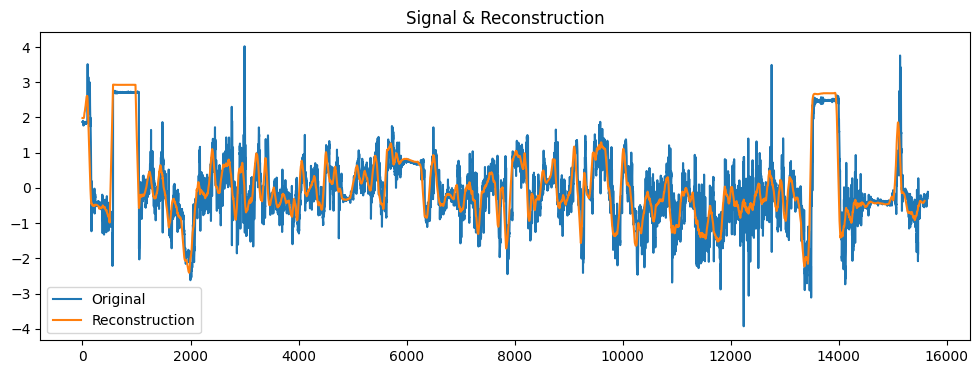

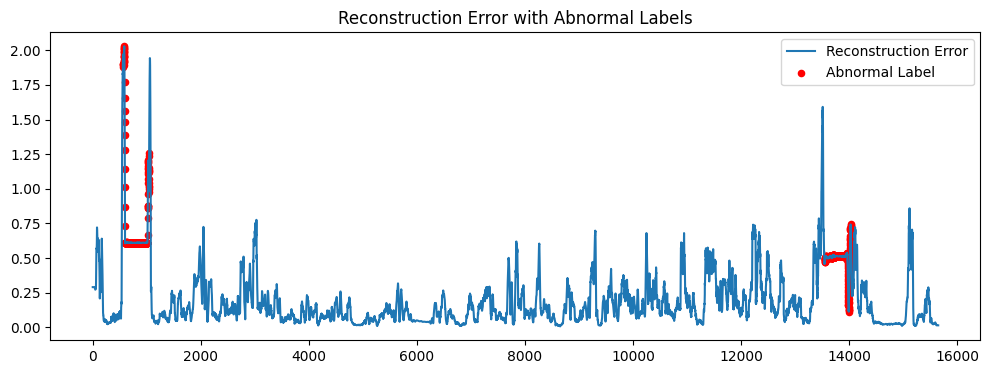

{'AUC-PR': 0.428228969582527,
 'AUC-ROC': 0.9545673858605956,
 'Standard-F1': 0.6686149791453365}

In [19]:
filename = file_list[820]
model = Linear.Model(config)
metrics = train_and_evaluate(
            path,
            filename,
            model,
            trainer,
            evaluator,
            win_size=win_size,
            epochs=1
        )

data_train, data, label = _read_file(path, filename)
reconstruction = evaluator.reconstruct(data, model, win_size)

plt.figure(figsize=(12,4))
plt.plot(data, label='Original')
plt.plot(reconstruction, label='Reconstruction')
plt.legend()
plt.title("Signal & Reconstruction")
plt.show()

# Reconstruction error
reconstruction_error = evaluator.reconstruction_error(data, model, win_size)
#reconstruction_error /= np.max(reconstruction_error)

plt.figure(figsize=(12,4))
plt.plot(reconstruction_error, label='Reconstruction Error')

# --- Highlight abnormal labels ---
anomaly_indices = np.where(label == 1)[0]
plt.scatter(anomaly_indices,
            reconstruction_error[anomaly_indices],
            color='red', s=20, label='Abnormal Label')

plt.legend()
plt.title("Reconstruction Error with Abnormal Labels")
plt.show()
metrics